In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="red"><b>ch4. 머신러닝 모형 최적화</b></font>
# 1절. 변수 선택과 차원 축소
## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임 (어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음 
    * 회귀계수 해석이 어려워짐. 모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘), p값이나 유의성 검정이 왜곡될 수 있음
- 모형의 학습 시간을 줄일 수 있음-주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택
## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)들로 축약**하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식, 통계 데이터분석(주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [5]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:,:-1], iris.species
iris_X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
pca = PCA(n_components=2)  # n_components : 주성분의 갯수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

In [9]:
# 각 주성분의 계수 : 각 주성분이 원래 특성과 어떤 관계가 있는지 나타내는 가중치
pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [10]:
# 설명 분산 : 각 주성분 벡터가 정보량을 얼마나 잘 표현하는지
pca.explained_variance_  

array([4.22824171, 0.24267075])

In [11]:
# 설명분산을 0~1 사이로 조정하여 설명 정도 
pca.explained_variance_ratio_

# 합쳐서 대략 97.8% 가량 설명할 수 있다는 뜻

array([0.92461872, 0.05306648])

## 1-3 상관관계 확인
- 각 변수들끼리의 상관관계를 확인하고 시각화 해서 종속변수와 상관관계가 높은 변수들만 선택

In [12]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';')  # delimeter=';' 사용 가능
redwine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [13]:
corr = redwine.corr()
# 상관관계 결과를 시각화

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# cmap의 종류 : https://jrc-park.tistory.com/155
# http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
# http://seaborn.pydata.org/examples/many_pairwise_correlations.html

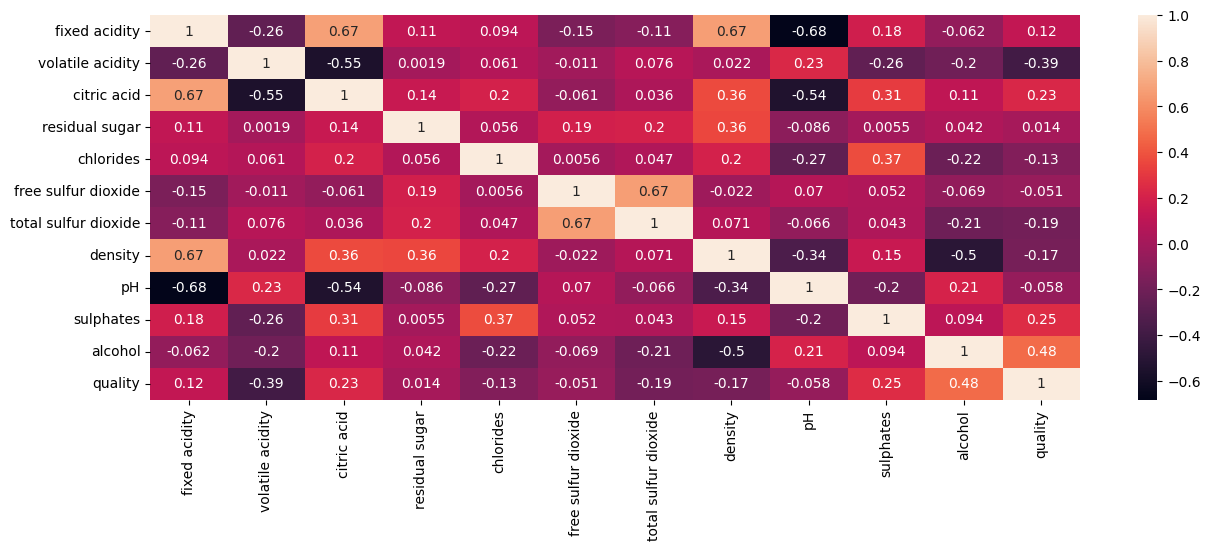

In [17]:
plt.figure(figsize=(15,5))
sns.heatmap(corr, annot=True)
plt.show()

In [22]:
np.triu(np.ones_like(corr), k=0)  # k=0 대각선(포함)을 기준으로 0과 1(위,upper)로 나뉘어짐!
np.triu(np.ones_like(corr), k=1)  # k=0 대각선(제외)을 기준으로 0과 1(위,upper)로 나뉘어짐!
np.tril(np.ones_like(corr), k=0)  # k=0 대각선(포함)을 기준으로 0과 1(아래,lower)로 나뉘어짐!
np.tril(np.ones_like(corr), k=1)  # k=0 대각선(제외)을 기준으로 0과 1(아래,lower)로 나뉘어짐!

array([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

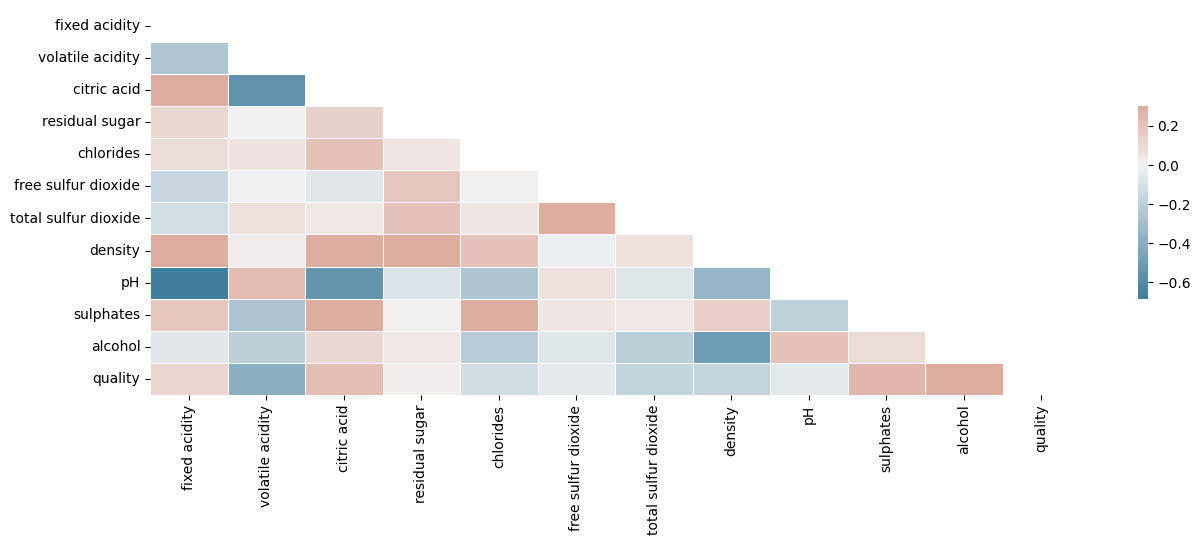

In [25]:
plt.figure(figsize=(15,5))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

## 1-4 분류모형의 Feature importance
- 분류모형의 feature_importance_ 속성은 각 독립변수들이 종속변수에 영향을 주는 정도
- LogisticRegression아니 SVC, MLP, GaussianVB 등은  feature_importance_가 없음
- 그 외 분류모형은 사용 가능

In [26]:
from sklearn.model_selection import train_test_split
X = redwine.iloc[:, :-1]
y = redwine.iloc[:,  -1]
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((1119, 11), (480, 11), (1119,), (480,))

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, # 트리 갯수 10개
                                 random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [33]:
rf_model.feature_importances_

array([0.07676913, 0.10324037, 0.08195872, 0.06014516, 0.07608101,
       0.05870071, 0.11436046, 0.08143966, 0.07422892, 0.11219325,
       0.1608826 ])

In [39]:
features = pd.DataFrame(np.c_[train_X.columns,rf_model.feature_importances_], columns=['features','importance'])

In [40]:
features.sort_values(by='importance', ascending=False, inplace=True)
features.reset_index(drop=True, inplace=True)
features.head()

,features,importance
0,alcohol,0.160883
1,total sulfur dioxide,0.11436
2,sulphates,0.112193
3,volatile acidity,0.10324
4,citric acid,0.081959


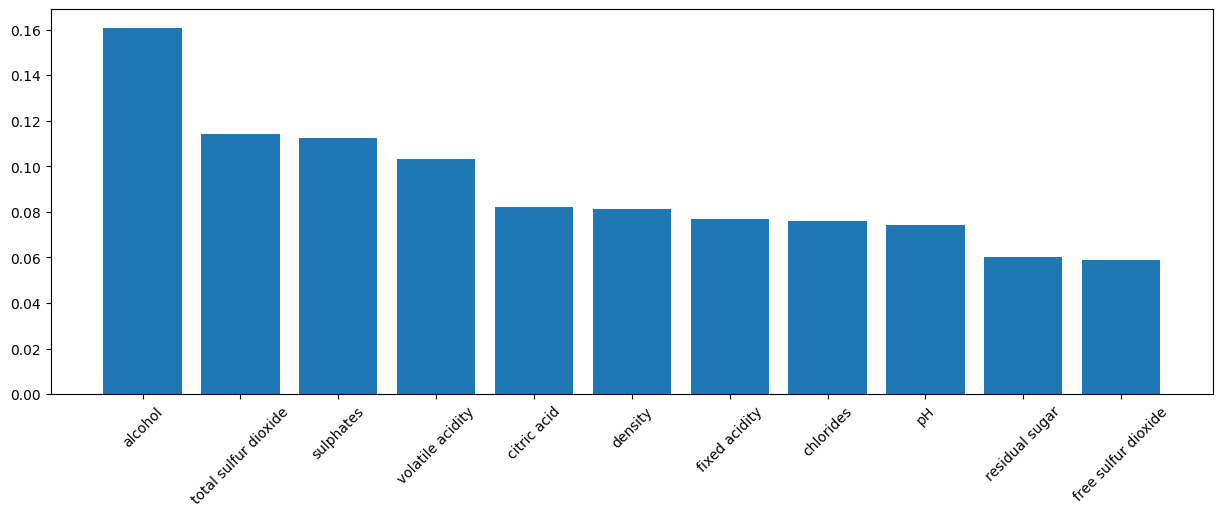

In [42]:
plt.figure(figsize=(15,5))
plt.bar(features.features, features.importance)
plt.xticks(rotation=45, fontsize=10)
plt.show()

In [45]:
# feature.importance 누적합
y_stack = np.cumsum(features.importance)
np.c_[features.importance, y_stack]

array([[0.1608826016077562, 0.1608826016077562],
       [0.11436046057694194, 0.27524306218469813],
       [0.11219325222117008, 0.38743631440586823],
       [0.10324037471095296, 0.49067668911682116],
       [0.08195871834134583, 0.572635407458167],
       [0.08143965812104385, 0.6540750655792108],
       [0.07676913113589132, 0.7308441967151021],
       [0.07608100737444921, 0.8069252040895514],
       [0.07422892161749584, 0.8811541257070472],
       [0.06014516346040248, 0.9412992891674496],
       [0.05870071083255032, 1.0]], dtype=object)

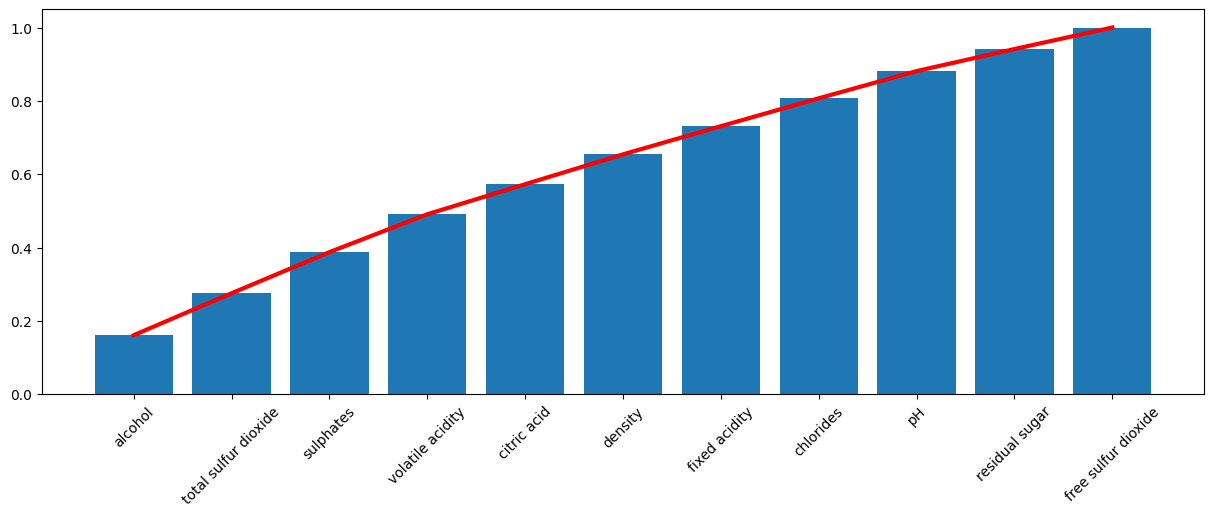

In [46]:
plt.figure(figsize=(15,5))
plt.bar(features.features, y_stack)
plt.plot(features.features, y_stack, color='red', lw=3)
plt.xticks(rotation=45, fontsize=10)
plt.show()

### RFE(Recursive Feature Elimination) 방식
- RFE 클래스를 이용 : 중요도에 따라 중요도가 낮은 변수부터 하나씩 제거해가면서 최종 선택된 변수 개수 만큼 중요도가 높은 변수를 찾는다

In [49]:
# 5개 특징이 남을 때까지 변수를 제거(기준 : feature_importances_)
from sklearn.feature_selection import RFE
rfe = RFE(rf_model,
         n_features_to_select=5).fit(train_X, train_y)
rfe.get_support()

array([False,  True, False, False, False, False,  True,  True, False,
        True,  True])

In [51]:
features_rfe = pd.DataFrame(np.c_[X.columns, rfe.get_support()],
                           columns=['feature', 'selected'])
features_rfe[features_rfe.selected==True]

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True


## 1-5 SelectKBest
- 가장 높은 score에 따라 k개의 특징을 선택

In [52]:
from sklearn.feature_selection import SelectKBest, chi2
# 가장 중요한 featuere 1개 추출

# chi2 : y는 범주형, x는 범주형, 양의 실수
# mutual_info : 비선형 데이터 고려
X_new = SelectKBest(f_
)

# 2절. 파라미터 탐색
- 하이퍼파라미터(사용자가 직접 설정할 수 있는 파라미터). 최적의 결과를 내는 하이퍼파라미터값
        1. validation_curve()  # 단일 하이퍼 파라미터 최적화 함수
        2. GridSearchCV() # 복수 하이퍼 파라미터 최적화 클래스

## 2-1 validation_curve() 
- param_name, param_range(리스트), scoring(성능기준지표) 매개변수로 받아 최적의 성능 계산

In [86]:
from sklearn.svm import SVC
import numpy as np
from sklearn.datasets import load_digits
digits = load_digits()
# digits.data : (1797, 64) 배열 (독립변수)
# digits.images : (1797, 8, 8) 배열
# digits.target : 1797 열 배열 (타겟변수)
# digits.target_names : 타겟변수 내용
X, y = digits.data, digits.target
model = SVC(probability=True).fit(X, y)  # probability=True:판별모형이라로 proba 가능
model

SVC(probability=True)

In [57]:
X.shape, y.shape

((1797, 64), (1797,))

In [74]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [58]:
X[0].reshape((8,8)), y[0], X[0].shape

(array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
        [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
        [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
        [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
        [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
        [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
        [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
        [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]]),
 0,
 (64,))

In [61]:
model.predict(X[0].reshape((1,-1)))

array([0])

In [66]:
# 예측확률
print(model.classes_)
print(model.predict_proba(X[0].reshape(1,-1)))

[0 1 2 3 4 5 6 7 8 9]
[[9.91375409e-01 1.94040896e-04 4.93789707e-04 8.97775615e-04
  5.87270019e-04 1.35501251e-03 7.19256525e-04 8.76056469e-04
  7.30721649e-04 2.77066723e-03]]


In [72]:
for c, p in zip(model.classes_, model.predict_proba(X[0].reshape(1,-1))[0] ):
    print("{}일 확률 : {:.3f}".format(c, p))

0일 확률 : 0.991
1일 확률 : 0.000
2일 확률 : 0.000
3일 확률 : 0.001
4일 확률 : 0.001
5일 확률 : 0.001
6일 확률 : 0.001
7일 확률 : 0.001
8일 확률 : 0.001
9일 확률 : 0.003


In [71]:
model.predict_proba(X[0].reshape(1,-1))[0]

array([9.91375409e-01, 1.94040896e-04, 4.93789707e-04, 8.97775615e-04,
       5.87270019e-04, 1.35501251e-03, 7.19256525e-04, 8.76056469e-04,
       7.30721649e-04, 2.77066723e-03])

In [76]:
model.score(X, y)

0.996661101836394

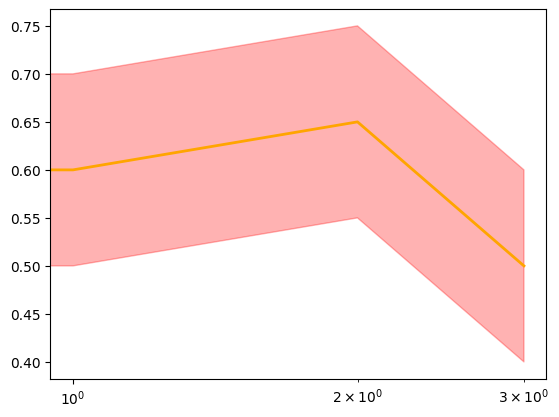

In [79]:
range_ = np.array([0,1,2,3])
score = np.array([0.5, 0.6, 0.65, 0.5])
plt.semilogx(range_, score, color='orange', lw=2)
plt.fill_between(range_, score-0.1, score+0.1, color='red', alpha=0.3)
plt.show()

In [89]:
# SVC() 모형에서 C 파라미터 값을 다음의 범위중 제일 좋은 값
param_range = np.linspace(10e-6, 10e-1, 10)
param_range = np.logspace(-6, -1, 10)  # 10의 -6승부터 10의 -1승까지 로그간격으로 균등분포 10개 추출

In [90]:
param_range

array([1.00000000e-06, 3.59381366e-06, 1.29154967e-05, 4.64158883e-05,
       1.66810054e-04, 5.99484250e-04, 2.15443469e-03, 7.74263683e-03,
       2.78255940e-02, 1.00000000e-01])

In [91]:
%time
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
    SVC(), X, y,
    param_name='gamma',
    param_range=param_range,  # list로 파라미터 전달
    cv=10,  # 교차 검증 : 데이터 10개중 1개씩 테스트 데이터로 검증하고 평균 score
    scoring='accuracy',
    n_jobs=-1  # 현 시스템의 모든 코어를 다 사용하라  # n_jobs=2  2개의 코어를 사용하라

)

CPU times: total: 0 ns
Wall time: 0 ns


In [97]:
train_score_mean = np.mean(train_score, axis=1)
test_score_mean = np.mean(test_score, axis=1)
train_score_std = np.std(train_score, axis=1)
test_score_std = np.std(test_score, axis=1)

In [98]:
train_score_mean, test_score_mean

(array([0.13836306, 0.72045751, 0.93439655, 0.96939318, 0.98775736,
        0.99789765, 1.        , 1.        , 1.        , 1.        ]),
 array([0.13871508, 0.70395717, 0.90871198, 0.94264742, 0.95880509,
        0.97495655, 0.97496586, 0.80522036, 0.19709497, 0.10463687]))

In [99]:
train_score_std, test_score_std

(array([0.06061766, 0.01032486, 0.00377997, 0.00261459, 0.00102754,
        0.00056702, 0.        , 0.        , 0.        , 0.        ]),
 array([0.06458693, 0.02805082, 0.03841992, 0.03207261, 0.02606765,
        0.02054497, 0.01863724, 0.05734476, 0.0509597 , 0.00764792]))

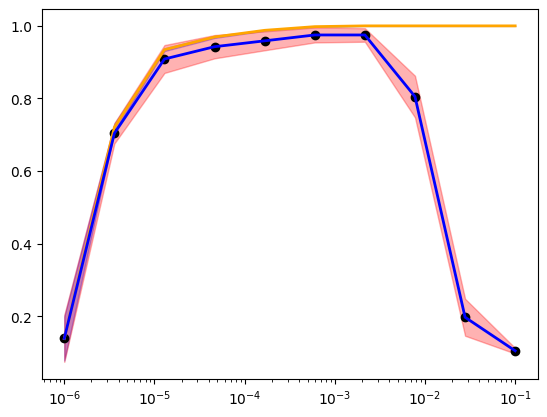

In [106]:
plt.semilogx(param_range, train_score_mean, color='orange', lw=2)
plt.fill_between(param_range, 
                 train_score_mean-train_score_std, 
                 train_score_mean+train_score_std, 
                 color='blue', alpha=0.3)
plt.semilogx(param_range, test_score_mean, color='blue', lw=2)
plt.fill_between(param_range, 
                 test_score_mean-test_score_std, 
                 test_score_mean+test_score_std, 
                 color='red', alpha=0.3)
plt.scatter(param_range, test_score_mean, c='k')
plt.show()

In [105]:
test_score_mean.argmax()

6

In [108]:
# 최적의 감마 값
gammar = param_range[6]
gammar

0.0021544346900318843

In [109]:
model = SVC(gamma=gammar).fit(X, y)
model.score(X, y) 

1.0

# 2-2 GridSearchCV
- 복수개의 하이퍼 파라미터 최적화 클래스
- 모형도 가지고 옴
- fit(), score(), predict(), predict_proba(), decision_function(), transform(), inverse_tranform() 메소드를 구현

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.svm import SVC

# 데이터 입력
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X, redwine_y = redwine.iloc[:, :-1], redwine.iloc[:, -1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [115]:
%%time
# SelectKBest 로 최적의 독립변수 k개 찾음 -> SVC에서 최적의 C값을 찾음
selection = SelectKBest(k=1)  # 가장 평가 점수가 높은 k개 찾음
svc = SVC(kernel='linear')  # 직선으로 나누는 가장 단순한 분류모형
pipeline = Pipeline([('select', selection), ('svc', svc)])
param_grid = dict(select__k = [4,5,6,7,8,9,10,11],
    svc__C = [0.1, 1, 10]  # 오차 범위 허용 정도 (큰C : 엄격, 작은C : 허용범위 큼)
)
grid_search = GridSearchCV(
                    pipeline, 
                    param_grid=param_grid,
                    cv=2,
                    verbose=1,
                    n_jobs=1
    
)
grid_search.fit(redwine_X.values, redwine_y.values)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
CPU times: total: 10min 19s
Wall time: 10min 31s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC(kernel='linear'))]),
             n_jobs=1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10]},
             verbose=1)

In [120]:
# 최적의 파라미터값
grid_search.best_params_

{'select__k': 9, 'svc__C': 1}

In [121]:
# 최적의 모형
model = grid_search.best_estimator_  # 이미 GridSearchCV가 fit 까지 완료해둠
model.score(redwine_X.values, redwine_y.values)

0.5878674171357098

In [122]:
model = SVC().fit(redwine_X.values, redwine_y.values)
model.score(redwine_X.values, redwine_y.values)

0.5103189493433395

# 3절. 자료 불균형 처리
- 단순 언더/오버 샘플링
- 단, 단순 오버 샘플링 시 소수의 데이터를 복사하므로, 과적합이 우려
- 오버 샘플링하는 방법 : SMOTE
## 3-1 SMOTE를 이용한 오버샘플링 전

In [3]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000,
                          n_features=10,
                          n_informative=5,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          n_classes=2,
                          weights=[0.99, 0.01],
                          random_state=42)
y.mean()

0.014

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size= 0.3,
                                                   stratify=y,
                                                   random_state=42
                                                   )

In [126]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, 
                                  max_features=2,
                                 random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [127]:
y_hat = rf_model.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test, y_hat)

array([[2958,    0],
       [  34,    8]], dtype=int64)

In [129]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.19      0.32        42

    accuracy                           0.99      3000
   macro avg       0.99      0.60      0.66      3000
weighted avg       0.99      0.99      0.98      3000



## 3-2 SMOTE를 이용한 전체 오버샘플링 후 데이터 셋 분리
- imbalaced-learn 라이브러리 install

In [6]:
import pandas as pd
import numpy as np
df = pd.DataFrame(np.c_[X,y])
df.iloc[:, -1].value_counts()

0.0    9860
1.0     140
Name: 10, dtype: int64

In [9]:
from imblearn.over_sampling import SMOTE
sm = SMOTE() # 0그룹 : 1그룹 = 1 : 1
# sm = SMOTE(sampling_strategy={0:9860, 1:420})  
X_resampled, y_resample = sm.fit_resample(X, y)
X_resampled.shape, y_resample.shape

((19720, 10), (19720,))

In [10]:
# 0그룹과 1그룹의 갯수
df = pd.DataFrame(np.c_[X_resampled, y_resample])
df.iloc[:,-1].value_counts()

0.0    9860
1.0    9860
Name: 10, dtype: int64

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resample,
                                                   test_size= 0.3,
                                                   stratify=y_resample,
                                                   random_state=42
                                                   )
rf_model = RandomForestClassifier(n_estimators=100, 
                                  max_features=2,
                                 random_state=42)
rf_model.fit(X_train, y_train)
y_hat = rf_model.predict(X_test)
confusion_matrix(y_test, y_hat)

array([[2949,    9],
       [  36, 2922]], dtype=int64)

In [15]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.99      0.99      2958

    accuracy                           0.99      5916
   macro avg       0.99      0.99      0.99      5916
weighted avg       0.99      0.99      0.99      5916



# 3-3 가중치 제어
- 자료 불균형 처리의 또 다른 방법
- sklearn의 예측 모형에서 class_weight 매개변수 설정

In [16]:
rf_model = RandomForestClassifier(n_estimators=100,
                                 max_features=2,
                                 class_weight={ 0:1 , 1:1.4 },  # 1그룹을 1.4배 더 중요하게 (1~2 사이로 적어주는게 일반적이다)
                                 random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 1.4}, max_features=2,
                       random_state=42)

In [18]:
y_hat = rf_model.predict(X_test)
confusion_matrix(y_test, y_hat)
print(classification_report(y_test, y_hat))  # 이건 이미 스무트를 한 결과에 가중치를 주게된 꼴이라.. 향후 연습을 해보던가 하자

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.99      0.99      2958

    accuracy                           0.99      5916
   macro avg       0.99      0.99      0.99      5916
weighted avg       0.99      0.99      0.99      5916



# 4절. 앙상블 모형
- 목적 : 여러 분류 모형을 하나의 메타 분류 모델로 연결하여, 개별 모형보다 더 좋은 일반화 성능을 달성
- 방법 : 
    * 하나의 메타 분류 알고리즘 이용 : 배깅, 부스팅
    * 여러 분류 알고리즘을 이용 : 투표(다수결)
- 배깅 vs 부스팅
    - 배깅 : 복원추출로 데이터를 뽑아 병렬 학습 후 score 가 높은 모델에 가중치 부여
        * 과적합 줄일 수 있음
        - 데이터가 충분하고 과적합을 방지하면서 안정적인 모델이 필요할때
        - RandomForestClassifier, Bage
    - 부스팅
        * 순차적으로 모델 학습. 앞의 모델에서 틀린 데이터의 50% 를 재학습
        * 오답에 가중치를 두는 것
        * 성능극대화

## 4-1 배깅 알고리즘

In [19]:
wine_df = pd.read_csv('data/wine.csv')
wine_df

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [21]:
X = wine_df.iloc[:, 1:]
y = wine_df['Class label']
X.shape, y.shape

((178, 13), (178,))

In [22]:
y.value_counts()

2    71
1    59
3    48
Name: Class label, dtype: int64

In [23]:
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=1)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((124, 13), (54, 13), (124,), (54,))

In [24]:
# 의사결정 나무 알고리즘
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='entropy', random_state=1).fit(train_X, train_y)
tree_model.score(test_X, test_y)

0.9074074074074074

In [26]:
# 배깅 알고리즘
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(estimator=tree_model,
                             n_estimators=500,
                             bootstrap=True,  # 복원 추출을 허용, 안뽑힌 것들 검증셋. False 설정시 검증 셋 없음.
                             bootstrap_features=False,  # 모든 feature 사용해서 학습
                             random_state=1
                             )
bag_model.fit(train_X, train_y)
bag_model.score(test_X, test_y)

0.9629629629629629

In [27]:
# 랜덤 포레스트 알고리즘
rf_model = RandomForestClassifier().fit(train_X, train_y)
rf_model.score(test_X, test_y)

1.0

### 부트스트래핑과 0.632규칙

In [28]:
np.random.choice(100, 100, replace=True) # 10개 데이터를 10개 복원 추출 뽑기

array([5, 7, 7, 0, 7, 4, 7, 2, 0, 0])

In [39]:
round(np.array([len(set(np.random.choice(10000, 10000, replace=True))) for i in range(10000)]).mean()/10000, 4)

0.6321

## 4-2 임의의 데이터를 만들어 최적 모형 검색

In [42]:
X, y = make_classification(n_samples=10000,
                          n_features=10,
                          n_informative=5,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           n_classes=2,
                           weights=[0.9, 0.1],
                           random_state=1                        
                        )

C:\Users\Admin\AppData\Local\Temp\ipykernel_95612\3322787509.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:,0], X[:,1], cmap=y)


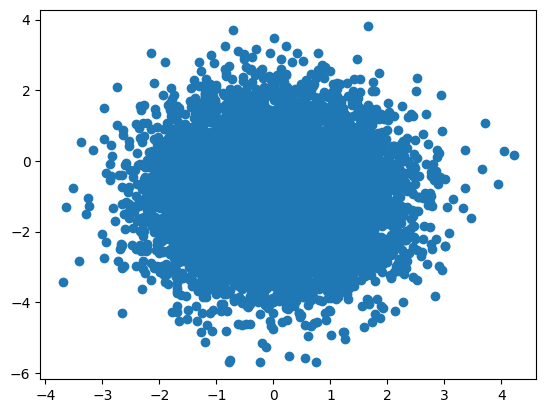

In [43]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], cmap=y)


In [45]:
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=1)
sm = SMOTE()
resampled_X, resampled_y = sm.fit_resample(train_X, train_y)
resampled_X.shape, resampled_y.shape, test_X.shape, test_y.shape

((12556, 10), (12556,), (3000, 10), (3000,))

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score
def model_measure(model, train_X=resampled_X, train_y=resampled_y,
                 test_X=test_X, test_y=test_y):
    '매개변수로 들어온 model 학습후 accuracy, precision, recall, f1score를 반환'
    model.fit(train_X, train_y)
    y_hat = model.predict(test_X)
    accuracy = model.score(test_X, test_y)
    precision = precision_score(test_y, y_hat)
    recall = recall_score(test_y, y_hat)
    f1score = f1_score(test_y, y_hat)
    return "정확도 : {:3f}, 정밀도 : {:3f}, 재현율 : {:3f}, f1 : {:3f}".format(accuracy,
                                                                        precision,
                                                                        recall,
                                                                        f1score)    

In [55]:
from sklearn.svm import SVC
model_measure(SVC(random_state=42))

'정확도 : 0.949667, 정밀도 : 0.691748, 재현율 : 0.922330, f1 : 0.790569'

In [54]:
model_measure(RandomForestClassifier(n_estimators=100,
                                    max_features=2,
                                    random_state=42))

'정확도 : 0.960667, 정밀도 : 0.792049, 재현율 : 0.838188, f1 : 0.814465'

## 4-3 부스팅 알고리즘
- Adaboost, XGB, LGBM, CatBoost

In [56]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier(random_state=42))

'정확도 : 0.904667, 정밀도 : 0.522863, 재현율 : 0.851133, f1 : 0.647783'

In [58]:
from xgboost import XGBClassifier
model_measure(XGBClassifier(max_depth=10, # tree 최대 깊이
                           n_estimator=100,  # 나무 갯수
                            learnin_rate=0.01  # 학습률  
                           ))

[17:45:33] WARNING: C:/buildkite-agent/builds/buildkite-windows-cpu-autoscaling-group-i-08de971ced8a8cdc6-1/xgboost/xgboost-ci-windows/src/learner.cc:767: 
Parameters: { "learnin_rate", "n_estimator" } are not used.



'정확도 : 0.964000, 정밀도 : 0.796460, 재현율 : 0.873786, f1 : 0.833333'

In [59]:
from lightgbm import LGBMClassifier  # pip install lightgbm
model_measure(LGBMClassifier(force_col_wise=True))

[LightGBM] [Info] Number of positive: 6278, number of negative: 6278
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12556, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


'정확도 : 0.962333, 정밀도 : 0.781609, 재현율 : 0.880259, f1 : 0.828006'

## 4-4 투표를 이용한 앙상블
- voting='hard' : 다수결
- voting='soft' : 확률의 합을 계산한 투표

In [60]:
# 데이터 생성
X, y = make_classification(n_samples=200,
                          n_features=2,
                          n_informative=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           n_classes=2,
                           weights=[0.9, 0.1],
                           random_state=42                        
                        )
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=42)

In [62]:
# 3개의 모델을 만들어서 투표 예정
xgb_model = XGBClassifier(max_depth=10,
                         n_estimators=100,
                         learning_rate=0.01,
                         eval_metric='logloss')
lgb_model= LGBMClassifier(force_col_wise=True, verbose=0, random_state=42)

In [61]:
rf_model = RandomForestClassifier(max_features=2, random_state=42)

In [63]:
print(model_measure(xgb_model))
print(model_measure(lgb_model))
print(model_measure(rf_model))

정확도 : 0.952333, 정밀도 : 0.719577, 재현율 : 0.880259, f1 : 0.791849
[LightGBM] [Info] Number of positive: 6278, number of negative: 6278
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12556, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
정확도 : 0.962333, 정밀도 : 0.781609, 재현율 : 0.880259, f1 : 0.828006
정확도 : 0.960667, 정밀도 : 0.792049, 재현율 : 0.838188, f1 : 0.814465


In [67]:
%%time
from sklearn.ensemble import VotingClassifier
v_model = VotingClassifier(estimators=[('rfm', rf_model),
                                      ('xgb', xgb_model),
                                      ('lgb', lgb_model)],
                          voting='hard')
model_measure(v_model)

[LightGBM] [Info] Number of positive: 6278, number of negative: 6278
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12556, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
CPU times: total: 26 s
Wall time: 8.79 s


'정확도 : 0.963000, 정밀도 : 0.789474, 재현율 : 0.873786, f1 : 0.829493'

In [68]:
%%time
v_model = VotingClassifier(estimators=[('rfm', rf_model),
                                      ('xgb', xgb_model),
                                      ('lgb', lgb_model)],
                          voting='soft')
model_measure(v_model)

[LightGBM] [Info] Number of positive: 6278, number of negative: 6278
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12556, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
CPU times: total: 26.1 s
Wall time: 8.84 s


'정확도 : 0.963667, 정밀도 : 0.787356, 재현율 : 0.886731, f1 : 0.834094'